# Эксперимент: Контрастивный анализ `host` и `field`

**Цель.** Оценить разделимость `host` и `field` внутри физических веток `M/K/G/F` до уровня, достаточного для host-scoring.

**Исследовательские вопросы.**
- Насколько хорошо контрастивная Gaussian-модель отделяет `host` от `field`?
- Какие `gauss_label` дают сильную разделимость, а какие остаются слабыми?
- Насколько ограниченный score `host_posterior` расходится между популяциями `host` и `field`?

**Что считается готовым результатом.**
- Посчитаны метрики готовности по всем contrastive labels.
- Построены компактные итоговые графики по accuracy и log-LR gap.
- Зафиксированы классы, которые стоит учитывать при следующей калибровке decision layer.


## Источник данных и контракт выполнения

Этот ноутбук сначала пытается прочитать `CONTRASTIVE_HOST_FIELD_VIEW`.
Если переменная не задана, используется встроенная пара источников:
- `lab.v_nasa_gaia_train_dwarfs` как `host`
- `lab.v_gaia_ref_mkgf_dwarfs` как `field`

**Ожидаемый вход.**
- либо один train-view с полями признаков, `spec_class` и бинарной host/field-разметкой;
- либо стандартные host/field relations проекта.

**Ключевой артефакт.**
- `data/eda/host/contrastive_gaussian_readiness.csv`



In [6]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'src').exists():
            return candidate
    raise RuntimeError('Repo root with src/ not found.')


def load_simple_dotenv(path: Path) -> dict[str, str]:
    env: dict[str, str] = {}
    if not path.exists():
        return env
    for line in path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        env[key.strip()] = value.strip()
    return env


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / 'src'
for path in (REPO_ROOT, SRC_ROOT):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

DOTENV_VALUES = load_simple_dotenv(REPO_ROOT / '.env')
for key, value in DOTENV_VALUES.items():
    os.environ.setdefault(key, value)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.core.getipython import get_ipython
from IPython.display import HTML, display

from analysis.host_eda.constants import (
    CONTRASTIVE_GAUSS_STATS_PATH,
    CONTRASTIVE_MIN_POPULATION_SIZE,
    CONTRASTIVE_SHRINK_ALPHA,
    CONTRASTIVE_VIEW_ENV,
)
from analysis.host_eda.contrastive import calc_contrastive_gauss_stats
from analysis.host_eda.data import get_engine
from analysis.visual_theme import (
    FIGSIZE_NOTEBOOK_DOUBLE,
    set_project_theme,
    spectral_class_color,
    style_axes,
)
from host_model import (
    CONTRASTIVE_POPULATION_COLUMN,
    DEFAULT_CONTRASTIVE_FIELD_VIEW,
    DEFAULT_CONTRASTIVE_HOST_VIEW,
    load_contrastive_training_from_db,
    load_default_contrastive_training_from_db,
)

set_project_theme()
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

print('Repo root:', REPO_ROOT)
print('DATABASE_URL available:', bool(os.environ.get('DATABASE_URL')))


Repo root: /Users/evgeniikuznetsov/Desktop/dspro-vkr
DATABASE_URL available: True


## План анализа

1. Получить имя обучающего view из окружения.
2. Загрузить контрастивную обучающую выборку тем же loader-ом, что использует offline EDA.
3. Посчитать таблицу готовности и сохранить CSV.
4. Построить итоговые графики, которые удобно интерпретировать в тексте ВКР.


In [7]:
view_name = os.getenv(CONTRASTIVE_VIEW_ENV, '').strip()

if view_name:
    print('Используется внешний contrastive view:', view_name)
    df_contrastive = load_contrastive_training_from_db(
        get_engine(),
        view_name=view_name,
        population_col=CONTRASTIVE_POPULATION_COLUMN,
    )
else:
    print('CONTRASTIVE_HOST_FIELD_VIEW не задан. Используются встроенные источники:')
    print('  host  ->', DEFAULT_CONTRASTIVE_HOST_VIEW)
    print('  field ->', DEFAULT_CONTRASTIVE_FIELD_VIEW)
    df_contrastive = load_default_contrastive_training_from_db(
        get_engine(),
        population_col=CONTRASTIVE_POPULATION_COLUMN,
        host_view=DEFAULT_CONTRASTIVE_HOST_VIEW,
        field_view=DEFAULT_CONTRASTIVE_FIELD_VIEW,
    )

stats = calc_contrastive_gauss_stats(
    df_contrastive,
    population_col=CONTRASTIVE_POPULATION_COLUMN,
    use_m_subclasses=True,
    shrink_alpha=CONTRASTIVE_SHRINK_ALPHA,
    min_population_size=CONTRASTIVE_MIN_POPULATION_SIZE,
)

CONTRASTIVE_GAUSS_STATS_PATH.parent.mkdir(parents=True, exist_ok=True)
stats.to_csv(CONTRASTIVE_GAUSS_STATS_PATH, index=False)
print('Сохранено:', CONTRASTIVE_GAUSS_STATS_PATH)
print('Число строк в обучающей выборке:', len(df_contrastive))
stats


CONTRASTIVE_HOST_FIELD_VIEW не задан. Используются встроенные источники:
  host  -> lab.v_nasa_gaia_train_dwarfs
  field -> lab.v_gaia_ref_mkgf_dwarfs
Сохранено: data/eda/host/contrastive_gaussian_readiness.csv
Число строк в обучающей выборке: 15394


,gauss_label,host_n,field_n,total_n,population_col,use_m_subclasses,shrink_alpha,model_version,score_mode,ready_for_contrastive_model,host_log_det_cov,field_log_det_cov,host_cond_cov,field_cond_cov,host_pd_cov,field_pd_cov,host_log_lr_mean_host,host_log_lr_mean_field,host_posterior_mean_host,host_posterior_mean_field,contrastive_margin_mean,contrastive_accuracy,centroid_distance_z
0,F,412,3000,3412,is_host,True,0.15,gaussian_host_field_v1,host_vs_field_log_lr_v1,True,-6.759234,-4.176987,9.471989,10.490130,True,True,1.291996,-2.339307,0.768476,0.323659,3.002632,0.692849,0.816066
1,G,1831,3000,4831,is_host,True,0.15,gaussian_host_field_v1,host_vs_field_log_lr_v1,True,-6.404170,-5.656087,22.687592,23.343233,True,True,1.079360,-1.484870,0.689264,0.280325,1.808396,0.772304,1.277453
2,K,927,3000,3927,is_host,True,0.15,gaussian_host_field_v1,host_vs_field_log_lr_v1,True,-8.423896,-4.533486,10.821693,11.475186,True,True,1.752143,-4.450059,0.840646,0.199153,4.258135,0.838299,0.868636
3,M_EARLY,117,2593,2710,is_host,True,0.15,gaussian_host_field_v1,host_vs_field_log_lr_v1,True,-6.825444,-6.047742,51.971477,70.224653,True,True,0.773202,-0.992343,0.673160,0.339388,1.442449,0.759041,0.568684
4,M_LATE,52,23,75,is_host,True,0.15,gaussian_host_field_v1,host_vs_field_log_lr_v1,True,-7.740442,-12.849969,533.027948,131.345216,True,True,17.512285,-2.499516,0.753660,0.111724,13.726244,0.813333,1.504041
5,M_MID,55,384,439,is_host,True,0.15,gaussian_host_field_v1,host_vs_field_log_lr_v1,True,-6.947926,-8.183156,227.671662,118.662981,True,True,1.435629,-0.635157,0.610846,0.355409,0.884598,0.829157,0.646794


## Производные метрики для интерпретации

Главная удобная производная метрика здесь — разница между средним `host_log_lr` у `host` и у `field`. Она помогает быстро увидеть, где контрастивная модель реально отделяет популяции.


In [8]:
plot_df = stats.copy()
plot_df['host_field_log_lr_gap'] = (
    plot_df['host_log_lr_mean_host'] - plot_df['host_log_lr_mean_field']
)
plot_df = plot_df.sort_values('contrastive_accuracy', ascending=False)
summary_columns = [
    'gauss_label',
    'host_n',
    'field_n',
    'contrastive_accuracy',
    'host_field_log_lr_gap',
    'host_posterior_mean_host',
    'host_posterior_mean_field',
]
summary_df = plot_df[summary_columns].reset_index(drop=True)

summary_view = summary_df.rename(
    columns={
        'gauss_label': 'Гауссов класс',
        'host_n': 'Host',
        'field_n': 'Field',
        'contrastive_accuracy': 'Точность',
        'host_field_log_lr_gap': 'Разрыв log-LR',
        'host_posterior_mean_host': 'mean(host_posterior | host)',
        'host_posterior_mean_field': 'mean(host_posterior | field)',
    }
).copy()

for column in (
    'Точность',
    'Разрыв log-LR',
    'mean(host_posterior | host)',
    'mean(host_posterior | field)',
):
    summary_view[column] = summary_view[column].map(lambda value: f'{value:.3f}')

summary_html = summary_view.to_html(
    index=False,
    border=0,
    classes=['contrastive-summary-table'],
)
summary_text = summary_view.to_string(index=False)
summary_csv_path = CONTRASTIVE_GAUSS_STATS_PATH.with_name(
    'contrastive_gaussian_summary.csv'
)
summary_html_path = CONTRASTIVE_GAUSS_STATS_PATH.with_name(
    'contrastive_gaussian_summary.html'
)
summary_style = """
<style>
.contrastive-summary-wrap {
    overflow-x: auto;
    margin: 0.5rem 0 1rem;
}
.contrastive-summary-table {
    border-collapse: collapse;
    font-size: 0.95rem;
    min-width: 780px;
}
.contrastive-summary-table th,
.contrastive-summary-table td {
    border: 1px solid #4b5563;
    padding: 0.45rem 0.65rem;
    text-align: right;
    white-space: nowrap;
}
.contrastive-summary-table th:first-child,
.contrastive-summary-table td:first-child {
    text-align: left;
}
.contrastive-summary-table thead th {
    background: #1f2937;
    color: #f9fafb;
}
</style>
""".strip()
summary_markup = (
    f'{summary_style}<div class="contrastive-summary-wrap">{summary_html}</div>'
)
summary_html_document = (
    '<!DOCTYPE html><html><head><meta charset="utf-8">'
    '<title>Contrastive Gaussian Summary</title>'
    + summary_style
    + '</head><body>'
    + '<h1>Contrastive-ready классы</h1>'
    + f'<div class="contrastive-summary-wrap">{summary_html}</div>'
    + '</body></html>'
)

summary_df.to_csv(summary_csv_path, index=False)
summary_html_path.write_text(summary_html_document, encoding='utf-8')
print('Сводная таблица сохранена:', summary_csv_path)
print('HTML-копия таблицы сохранена:', summary_html_path)


Сводная таблица сохранена: data/eda/host/contrastive_gaussian_summary.csv
HTML-копия таблицы сохранена: data/eda/host/contrastive_gaussian_summary.html


## Итоговые графики

Здесь визуализация нужна не для вычислений, а для компактного сравнения классов по двум главным сигналам: accuracy и среднему log-LR gap.


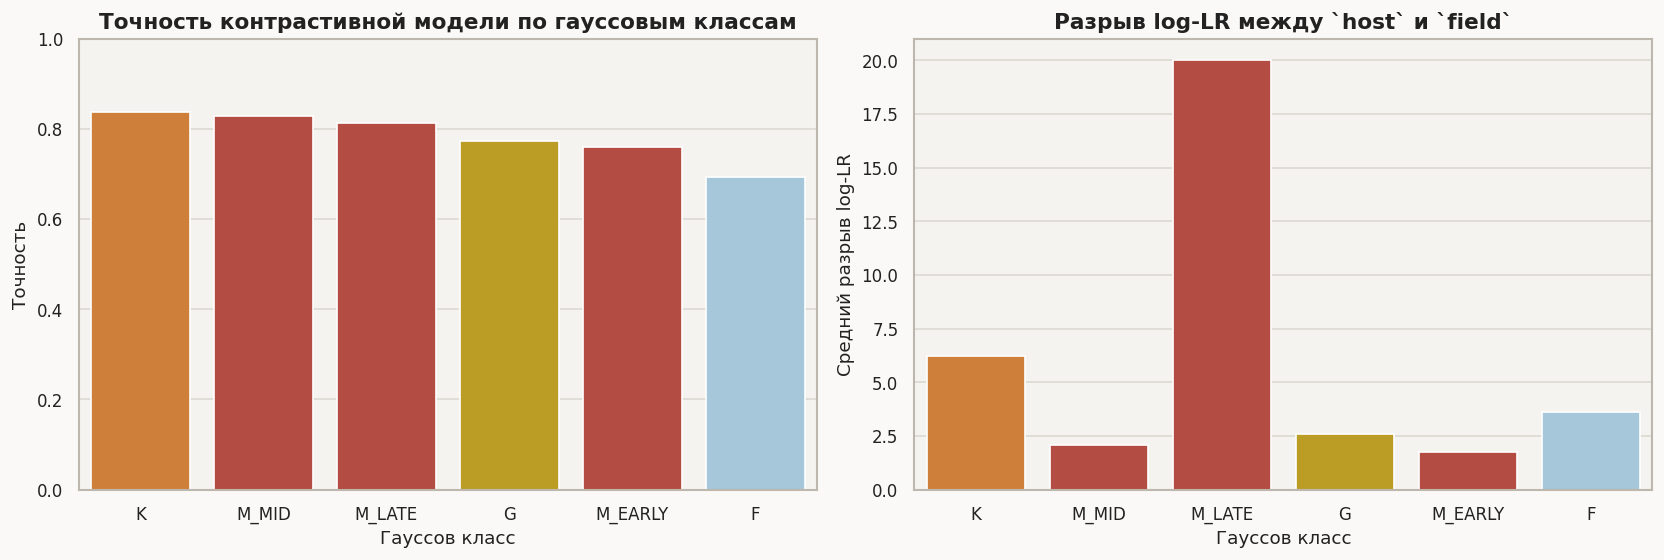

In [9]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_NOTEBOOK_DOUBLE)

bar_colors = [spectral_class_color(label) for label in plot_df['gauss_label']]

sns.barplot(
    data=plot_df,
    x='gauss_label',
    y='contrastive_accuracy',
    ax=axes[0],
    palette=bar_colors,
    hue='gauss_label',
    legend=False,
)
axes[0].set_title('Точность контрастивной модели по гауссовым классам')
axes[0].set_xlabel('Гауссов класс')
axes[0].set_ylabel('Точность')
axes[0].set_ylim(0.0, 1.0)

sns.barplot(
    data=plot_df,
    x='gauss_label',
    y='host_field_log_lr_gap',
    ax=axes[1],
    palette=bar_colors,
    hue='gauss_label',
    legend=False,
)
axes[1].set_title('Разрыв log-LR между `host` и `field`')
axes[1].set_xlabel('Гауссов класс')
axes[1].set_ylabel('Средний разрыв log-LR')

for axis in axes:
    style_axes(axis)

plt.tight_layout()
display(fig)
plt.close(fig)


## Краткая сводка по contrastive-ready классам

Ниже таблица выводится отдельным HTML-блоком с горизонтальным скроллом.
Если rich-renderer VS Code снова не покажет её корректно, сразу под ней
печатается plain-text fallback, а рядом уже лежит сохранённая HTML-копия.


In [10]:
print('Краткая сводка contrastive-ready классов:')
display(HTML(summary_markup))
print('Fallback plain-text table:')
print(summary_text)
print('Открыть HTML-копию можно по пути:', summary_html_path)


Краткая сводка contrastive-ready классов:


Гауссов класс,Host,Field,Точность,Разрыв log-LR,mean(host_posterior | host),mean(host_posterior | field)
K,927,3000,0.838,6.202,0.841,0.199
M_MID,55,384,0.829,2.071,0.611,0.355
M_LATE,52,23,0.813,20.012,0.754,0.112
G,1831,3000,0.772,2.564,0.689,0.280
M_EARLY,117,2593,0.759,1.766,0.673,0.339
F,412,3000,0.693,3.631,0.768,0.324


Fallback plain-text table:
Гауссов класс  Host  Field Точность Разрыв log-LR mean(host_posterior | host) mean(host_posterior | field)
            K   927   3000    0.838         6.202                       0.841                        0.199
        M_MID    55    384    0.829         2.071                       0.611                        0.355
       M_LATE    52     23    0.813        20.012                       0.754                        0.112
            G  1831   3000    0.772         2.564                       0.689                        0.280
      M_EARLY   117   2593    0.759         1.766                       0.673                        0.339
            F   412   3000    0.693         3.631                       0.768                        0.324
Открыть HTML-копию можно по пути: data/eda/host/contrastive_gaussian_summary.html


## Интерпретация

При чтении этой таблицы и графиков важно смотреть на три вещи одновременно:
- `contrastive_accuracy`;
- `host_field_log_lr_gap`;
- разницу между `host_posterior_mean_host` и `host_posterior_mean_field`.

Если accuracy низкая и gap мал, bounded host-score будет слабым и для ranking, и для калибровки decision layer. Если же accuracy и gap высокие, ветка готова к более уверенной prioritization.


## Следующий шаг

После этого можно переходить к следующей итерации калибровки и проверять, как новые контрастивные сигналы влияют на распределение `final_score` и на границы `HIGH / MEDIUM / LOW`.
